# Project 1 - E-commerce

## Business problem

A global online retail company is struggling to understand customer behavior, identify high-value customers, 
and uncover product purchasing patterns. This lack of insight results in inefficient marketing strategies, 
poor customer targeting, and missed opportunities for cross-selling and revenue optimization.

## Objectives

#### 1) Customer Segmentation (Understand customers)

To segment customers into distinct groups based on purchasing behavior using recency, frequency, and monetary (RFM) metrics 
in order to identify meaningful customer segments for targeted business strategies.

To derive insights including:

* Customer types (frequent, one-time, inactive, bulk, seasonal)
* Behavioral patterns (high-frequency vs high-spend, low-frequency vs high-spend)
* Customer lifecycle stages (recent, active, inactive)

Business impact:

This segmentation will enable targeted marketing, improved customer retention, and better resource allocation

#### 2) Customer Value Prediction (Predict customers)

To develop a classification model that predicts whether a customer is high-value or low-value based on purchasing behavior, leveraging 
insights derived from customer segmentation to enable targeted marketing and optimized resource allocation.

#### 3) Market Basket Analysis (Understand products)

To identify relationships between products using association rule mining, in order to discover frequently co-purchased items 
and support product recommendation and cross-selling strategies.



#### Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Load

In [44]:
ecommerce_df = pd.read_csv("E-commerce.csv")

In [45]:
ecommerce_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


#### Data Understanding

This is a transactional level data of customer purchases from an online retail store

* InvoiceNo - A nominal 6-digit unique transaction number, c-cancellation

* StockCode (Product Item Code) -  A nominal 5-digit unique number for each distinct product

* Description - Product name

* Quantity - Quantities purchased per transaction

* InvoiceDate (Invoice Date Time) - The date and time of transaction 

* UnitPrice - Product price per unit in sterling

* CustomerID - A nominal 5-digit unique number for each customer

* Country - Country of the customer

#### Renaming columns for clarity

In [46]:
ecommerce_df.rename(columns={'StockCode':'ProductCode',
                             'Description': 'ProductName'}, inplace=True)

In [47]:
ecommerce_df.head()

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Initial Data Exploration and Handling

In [48]:
ecommerce_df.shape

(541909, 8)

The dataset contains 5,41,909 rows and 8 columns

In [49]:
ecommerce_df.isnull().sum()

InvoiceNo           0
ProductCode         0
ProductName      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#### Validating missing values of ProductName in CustomerID

In [50]:
ecommerce_df[
    ecommerce_df['ProductName'].isnull() &
    ecommerce_df['CustomerID'].notnull()
].shape

(0, 8)

In [51]:
ecommerce_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   ProductCode  541909 non-null  object 
 2   ProductName  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


`ISSUES`

1) InvoiceDate is stored as object
2) CustomerID has missing values
3) CustomerID is stored as float
4) ProductName has missing values

#### Converting InvoiceDate to DateTime

In [52]:
ecommerce_df['InvoiceDate'] = pd.to_datetime(ecommerce_df['InvoiceDate'])

#### Handling Missing CustomerID 

In [53]:
ecommerce_df['CustomerID'].isnull().sum()

np.int64(135080)

`OBSERVATION`

The CustomerID column contains 1,35,080 missing values.

#### Creating new dataframe

In [54]:
ecommerce_cleaned = ecommerce_df.dropna(subset=['CustomerID']).copy()

`ACTION`

Rows with missing CustomerID values were removed by creating a new cleaned dataset.

`REASON`

Since the objective of the project focuses on customer purchasing behavior,
a valid customer identifier is<br> essential for analysis.
Rows without CustomerID cannot be used for customer-level insights.

#### New dataframe shape

In [55]:
ecommerce_cleaned.shape

(406829, 8)

The new dataset contains 4,06,829 rows and 8 columns

#### CustomerID format validation

In [56]:
(ecommerce_cleaned['CustomerID'] % 1 != 0).sum()

np.int64(0)

There are zero CustomerID values with decimals other than .0

#### Converting CustomerID to INT

In [57]:
ecommerce_cleaned['CustomerID'] = ecommerce_cleaned['CustomerID'].astype(int)

#### Validating datatypes after conversion

In [58]:
ecommerce_cleaned.dtypes

InvoiceNo              object
ProductCode            object
ProductName            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

#### ProductName Handling

These missing rows were already removed during the handling of missing CustomerID. Hence, no separate handling needed.

## Exploratory Data Analysis (EDA)

#### Distribution of Quantity

In [59]:
ecommerce_cleaned['Quantity'].describe()

count    406829.000000
mean         12.061303
std         248.693370
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

`OBSERVATIONS`

* The Quantity contains both positive and negative values.
* The minimum quantity is -80995. Negative values might indicate product cancellations or returns. This needs to be verified.
* The maximum quantity is 80995. Why is the maximum quantity so high?
* Most transactions fall between 2 to 12 items.
* The large difference between mean and median suggests a right skewed distribution with extreme outliers.
* Data is highly spread out due to some extreme values. The standard deviation is significantly higher than the mean.

#### Validating negative values

In [60]:
ecommerce_cleaned[ecommerce_cleaned['Quantity'] < 0][['InvoiceNo','Quantity']].head()

,InvoiceNo,Quantity
141,C536379,-1
154,C536383,-1
235,C536391,-12
236,C536391,-24
237,C536391,-24


`OBSERVATION`

* Negative values does indicate product cancellations. Hence, verified.

#### Distribution of UnitPrice

In [61]:
ecommerce_cleaned['UnitPrice'].describe()

count    406829.000000
mean          3.460471
std          69.315162
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max       38970.000000
Name: UnitPrice, dtype: float64

`OBSERVATIONS`

* Most UnitPrices fall within a range of 1 to 4.
* Minimim price is 0. How can prices be 0? Free items? This needs to be verified.
* Maximum price is 38970. This needs to be verified.
* The difference between mean and median suggests a right skewed distribution. Few items are pulling the average up.
* Standard deviation is high compared to mean. This suggests that the data is highly spread out.

#### Unique customers

In [62]:
ecommerce_cleaned['CustomerID'].nunique()

4372

`OBSERVATION`

* The dataset contains 4,372 unique customers
* With a large number of transactions (4,06,829), having 4,372 unique customers means stronger participation

#### Distribution of Country

In [63]:
ecommerce_cleaned['Country'].value_counts().head(10)

Country
United Kingdom    361878
Germany             9495
France              8491
EIRE                7485
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         1877
Portugal            1480
Australia           1259
Name: count, dtype: int64

`OBSERVATION`

* The data is highly concentrated in the United Kingdom, with significantly fewer transactions from other countries, although it includes customers from multiple international markets

#### Unique Products

In [64]:
ecommerce_cleaned['ProductName'].nunique()

3896

`OBSERVATION`

* The data contains 3,896 unique products, indicating a wide variety of items offered by the business

#### Top Products

In [65]:
ecommerce_cleaned['ProductName'].value_counts().head(10)

ProductName
WHITE HANGING HEART T-LIGHT HOLDER    2070
REGENCY CAKESTAND 3 TIER              1905
JUMBO BAG RED RETROSPOT               1662
ASSORTED COLOUR BIRD ORNAMENT         1418
PARTY BUNTING                         1416
LUNCH BAG RED RETROSPOT               1358
SET OF 3 CAKE TINS PANTRY DESIGN      1232
POSTAGE                               1196
LUNCH BAG  BLACK SKULL.               1126
PACK OF 72 RETROSPOT CAKE CASES       1080
Name: count, dtype: int64

`OBSERVATION`

* Is POSTAGE a product? This needs to be verified.

#### Entries of POSTAGE

In [66]:
ecommerce_cleaned[ecommerce_cleaned['ProductName'] == 'POSTAGE'].head(10)

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.0,12583,France
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.0,12791,Netherlands
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00,18.0,12662,Germany
5073,536840,POST,POSTAGE,1,2010-12-02 18:27:00,18.0,12738,Germany
5258,536852,POST,POSTAGE,1,2010-12-03 09:51:00,18.0,12686,France
5325,536858,POST,POSTAGE,2,2010-12-03 10:36:00,40.0,13520,Switzerland
5369,536861,POST,POSTAGE,3,2010-12-03 10:44:00,18.0,12427,Germany
6602,536967,POST,POSTAGE,1,2010-12-03 12:57:00,18.0,12600,Germany
6676,536974,POST,POSTAGE,2,2010-12-03 13:59:00,18.0,12682,France
6973,536983,POST,POSTAGE,1,2010-12-03 14:30:00,18.0,12712,Germany


#### Number of Invoices containing POSTAGE

In [67]:
ecommerce_cleaned[ecommerce_cleaned['ProductName'] == 'POSTAGE']['InvoiceNo'].nunique()

1194

`OBSERVATION`

* It appears in many orders

#### Is POSTAGE bought with other items?

In [68]:
ecommerce_cleaned[ecommerce_cleaned['InvoiceNo'] == '536967']

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6602,536967,POST,POSTAGE,1,2010-12-03 12:57:00,18.00,12600,Germany
6603,536967,85099B,JUMBO BAG RED RETROSPOT,30,2010-12-03 12:57:00,1.95,12600,Germany


In [69]:
ecommerce_cleaned[ecommerce_cleaned['InvoiceNo'] == '536852'].head(10)

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
5252,536852,22549,PICTURE DOMINOES,12,2010-12-03 09:51:00,1.45,12686,France
5253,536852,22544,MINI JIGSAW SPACEBOY,24,2010-12-03 09:51:00,0.42,12686,France
5254,536852,22539,MINI JIGSAW DOLLY GIRL,24,2010-12-03 09:51:00,0.42,12686,France
5255,536852,22661,CHARLOTTE BAG DOLLY GIRL DESIGN,10,2010-12-03 09:51:00,0.85,12686,France
5256,536852,21791,VINTAGE HEADS AND TAILS CARD GAME,12,2010-12-03 09:51:00,1.25,12686,France
5257,536852,21786,POLKADOT RAIN HAT,24,2010-12-03 09:51:00,0.42,12686,France
5258,536852,POST,POSTAGE,1,2010-12-03 09:51:00,18.00,12686,France


In [70]:
ecommerce_cleaned[ecommerce_cleaned['InvoiceNo'] == '536403'].head(10)

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
385,536403,22867,HAND WARMER BIRD DESIGN,96,2010-12-01 11:27:00,1.85,12791,Netherlands
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.00,12791,Netherlands


#### Any customers who bought only POSTAGE?

In [71]:
ecommerce_cleaned.groupby('CustomerID')['ProductName'].apply(
    lambda x: set(x) == {'POSTAGE'}
).sum()

np.int64(0)

`VERIFICATION`

* Multiple invoices were inspected, and in each case, POSTAGE appeared alongside several products purchased by a single customer
* A customer-level check confirmed that no customer has purchased only POSTAGE without buying other products

`INSIGHT`

* POSTAGE is not a product selected by customers but is associated with transactions, representing a shipping or delivery charge

`ACTION`

* POSTAGE will be excluded from product-level analysis, such as Market Basket Analysis

#### Customer activity based on item purchase volume

In [72]:
ecommerce_cleaned['CustomerID'].value_counts().head(10)

CustomerID
17841    7983
14911    5903
14096    5128
12748    4642
14606    2782
15311    2491
14646    2085
13089    1857
13263    1677
14298    1640
Name: count, dtype: int64

`OBSERVATIONS`

* Certain customers appear very frequently in the dataset, indicating a higher number of purchased items
* This reflects high customer activity, where some customers make frequent purchases or buy multiple items per transaction
* These are highly active customers

#### Number of unique transactions per customer

In [73]:
ecommerce_cleaned.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False).head()

CustomerID
14911    248
12748    224
17841    169
14606    128
15311    118
Name: InvoiceNo, dtype: int64

`OBSERVATIONS`

* Certain customers have a significantly higher number of transactions, with some customers making over 200 purchases
* These customers represent highly active and loyal users who frequenly engage with the business

#### Time Coverage of the Transactions

In [74]:
ecommerce_cleaned['InvoiceDate'].min()

Timestamp('2010-12-01 08:26:00')

In [75]:
ecommerce_cleaned['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

`OBSERVATIONS`

* The dataset contains transactions from `1st December 2010` to `9th December 2011`
* This indicates that the dataset spans approximately one year of transactional data, which is sufficient for analyzing customer purchasing behavior over time

#### Which days had the highest number of transactions?

In [76]:
ecommerce_cleaned['InvoiceDate'].dt.date.value_counts().head(10)

InvoiceDate
2011-11-06    3434
2011-12-05    3398
2011-11-23    3332
2011-11-10    3194
2011-11-20    3112
2011-11-17    3034
2011-11-14    2964
2011-10-30    2907
2011-10-06    2870
2011-11-22    2862
Name: count, dtype: int64

`OBSERVATIONS`

* The highest transaction volumes are observed on specific days, primarily concentrated in November and December 2011
* This indicates a surge in customer activity during the end-of-year period, likely driven by seasonal demand and festive purchasing behaviour

#### How many transactions per month?

In [77]:
ecommerce_cleaned['InvoiceDate'].dt.to_period('M').value_counts().sort_index()

InvoiceDate
2010-12    26850
2011-01    21912
2011-02    20363
2011-03    27822
2011-04    23198
2011-05    28908
2011-06    27836
2011-07    27502
2011-08    27662
2011-09    40822
2011-10    50695
2011-11    65598
2011-12    17661
Freq: M, Name: count, dtype: int64

`OBSERVATIONS`

* Transaction volume remain relatively stable from `January to August 2011`, followed by a significant increase from `September`, peaking in `November 2011`
* A drop is observed in December, however this is due to incomplete data for the month
* This increasing trend towards the end of the year indicates a strong seasonal demand, likely driven by festive and holiday shopping periods

### Visualization

#### Distribution of Unit Price

In [78]:
sns.set_style("ticks")

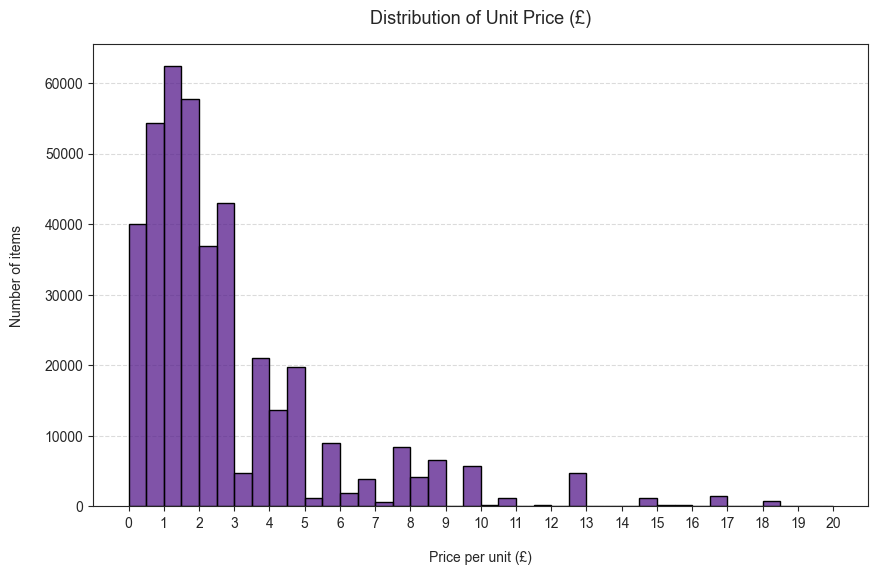

In [79]:
plt.figure(figsize=(10,6))

plt.grid(axis='y',linestyle='--',alpha=0.7)

sns.histplot(data=ecommerce_cleaned,
            x='UnitPrice',
            color="#551A8B",
            edgecolor="black",
            bins=40,
            binrange=(0,20))

plt.xticks(np.arange(0, 21, 1))

plt.title("Distribution of Unit Price (£)",fontsize=13, pad=15)
plt.xlabel("Price per unit (£)", labelpad=15)
plt.ylabel("Number of items", labelpad=15)

plt.show()

`OBSERVATIONS`

* The business `primarily sells low-cost items`, with most products priced within a narrow range of `£1-£3`, indicating a focus on affordable or frequently purchased goods
* A small number of higher priced items exist but contribute less to overall transaction volume
* The pricing structure suggests a `low-price, high-volume business model`
* The distribution is highly right-skewed, indicating the presence of a few expensive products that extend the price range

#### Distribution of Quantity

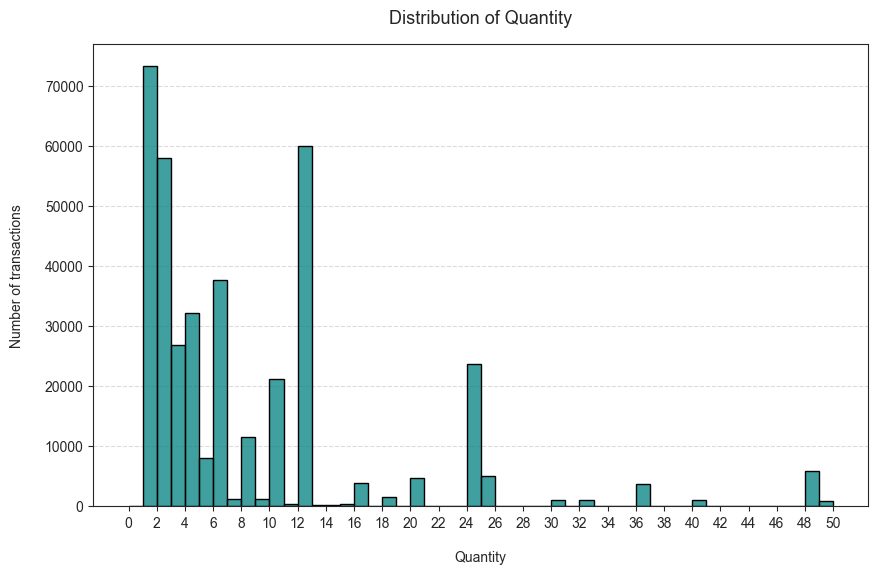

In [80]:
plt.figure(figsize=(10,6))

plt.grid(axis='y',linestyle='--',alpha=0.7)

sns.histplot(data=ecommerce_cleaned,
            x='Quantity',
            color="#008080",
            edgecolor="black",
            bins=50,
            binrange=(0,50))

plt.xticks(np.arange(0, 51, 2))

plt.title("Distribution of Quantity",fontsize=13, pad=15)
plt.xlabel("Quantity", labelpad=15)
plt.ylabel("Number of transactions", labelpad=15)

plt.show()

`OBSERVATIONS`

* The majority of transactions involve small quantities, primarily between 1 and 6 items per order, with a peak around lower values.
* The distribution is heavily right-skewed, with a long tail extending towards higher quantities
* The overall distribution suggests a mixed purchasing behavior, where retail customers contirbute to a higher number of transactions with smaller quantities, while wholesale customers contribute through fewer but large-volume purchases
* The sharp peaks at multiples of 12 suggests that a significant portion of the customer base consists of `small businesses (B2B)` who purchase inventory in standardized case sizes
* This pattern aligns with the dataset description, confirming the presence of both `retail (B2C)` and `wholesale (B2B)` purchasing behavior within the business

### Data Cleaning

### 1) Handling cancellation transactions (Negative Quantity)

#### Invoice Type Identification

In [97]:
ecommerce_cleaned['InvoiceNo'].astype(str).str[0].value_counts()

InvoiceNo
5    397924
C      8905
Name: count, dtype: int64

`OBSERVATION`

* The dataset contains invoice numbers that are either numeric or prefixed with "C"
* Numeric invoice numbers represent standard purchase transactions, while invoices starting with "C" indicate cancellations
* No other invoice prefixes are observed, confirming that cancellations are the only special transaction type present

#### Identification of Cancelled Transactions

In [96]:
ecommerce_cleaned[ecommerce_cleaned['Quantity'] < 0].head()

,InvoiceNo,ProductCode,ProductName,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom


`OBSERVATION`

* The dataset contains transactions with negative quantities, where invoice numbers start with 'C'

`INSIGHT`

* These entries represent product cancellations and do not reflect actual purchases

`ACTION`

* Negative quantity transactions will be removed to ensure accurate analysis of customer purchasing behaviour and revenue
* Verification needs to be done to ensure that the total sum of negative quantity matches with the cancelled transactions

#### Validation of cancellation transactions

#### Total sum of negative quantity

In [110]:
ecommerce_cleaned[ecommerce_cleaned['Quantity'] < 0]['Quantity'].sum()

np.int64(0)

#### Total sum of negative quantity for Invoices that starts with "C"

In [111]:
ecommerce_cleaned[
    ecommerce_cleaned['InvoiceNo'].astype(str).str.startswith('C')
    ]['Quantity'].sum()

np.int64(0)

`OBSERVATION`

* The total sum of negative quantities in the dataset is -2,74,808
* The total sum of quantities for invoices starting with "C" is also -2,74,808

`INSIGHT`

* This confirms that all the negative quantity transactions are associated with invoices prefixed with "C", indicating cancellations
* No negative quantities are present in standard transactions

`ACTION`

* Therefore, these transactions are safely removed without losing valid sales data 


#### Removal of cancellation transactions

In [106]:
ecommerce_cleaned = ecommerce_cleaned[ecommerce_cleaned['Quantity'] > 0]

In [112]:
ecommerce_cleaned.shape

(397924, 8)

The updated dataset contains 3,97,924 rows and 8 columns after removing cancellation transactions